# Outlier Detection

This notebook applies residual-based outlier detection to the naive benchmark and the selected model. The comparison is based on overlap, selected sample size, and the absolute residual magnitude of flagged observations.

In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from arch import arch_model
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================================================
# 1. GLOBAL SETTINGS
# =========================================================

# time resolution and target variable
time_resolution = "qh"   # "qh" or "h"
target_col = "id1"       # "id1" or "id3"
model = "nn"             # "lgb", "xgb", or "nn"

# anomaly settings
IF_TOP_Q = 0.99
MAD_THRESHOLD = 3.5
IQR_MULTIPLIER = 1.5
IF_N_ESTIMATORS = 300
IF_RANDOM_STATE = 42

# GARCH settings
GARCH_P = 1
GARCH_Q = 1
GARCH_DIST = "normal"

In [3]:
# =========================================================
# 2. PREDICTOR DEFINITIONS
# =========================================================

# kept aligned with 03b_compare_models.ipynb
predictor_vars = [
    "day_ahead_price",
    "load_actual_mw",
    "load_delta",
    "wind_delta",
    "solar_delta",
    "import_delta",
    "export_delta",
    "net_import_total",
    "fossil_gas_mw",
    "biomass_mw",
    "hydro_run_of_river_and_poundage_mw",
    "hydro_water_reservoir_mw",
    "hydro_pumped_storage_mw",
    "solar_mw",
    "wind_onshore_mw",
    "outage_total_true",
    "ramp_outage",
]

lagged_fundamental_vars = [
    "load_delta",
    "wind_delta",
    "solar_delta",
    "net_import_total",
    "ramp_outage",
]

fundamental_lags = [1, 2]

time_features = [
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "free_day",
]

In [4]:
# =========================================================
# 3. LOAD DATA
# =========================================================

df = pd.read_csv(
    f"../data/{model}_predictions_{time_resolution}.csv",
    parse_dates=["datetime"],
)

df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("Europe/Vienna")
df = df.sort_values("datetime").reset_index(drop=True)
df = df.loc[:, ~df.columns.duplicated()].copy()

print("data loaded:", df.shape)
print("start:", df["datetime"].min())
print("end:  ", df["datetime"].max())

data loaded: (34944, 35)
start: 2025-01-01 00:00:00+01:00
end:   2025-12-31 23:45:00+01:00


In [5]:
# =========================================================
# 4. HELPER FUNCTIONS
# =========================================================

def pick_first_existing(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise KeyError(f"None of these columns found: {candidates}")

    return None


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mad_scores(x):
    x = np.asarray(x, dtype=float)
    median = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - median))

    if mad == 0 or np.isnan(mad):
        return np.full_like(x, np.nan, dtype=float)

    return 0.6745 * (x - median) / mad


def mad_flags(x, threshold=MAD_THRESHOLD):
    scores = mad_scores(x)
    return np.abs(scores) > threshold, scores


def iqr_bounds(x, multiplier=IQR_MULTIPLIER):
    x = np.asarray(x, dtype=float)
    q1 = np.nanpercentile(x, 25)
    q3 = np.nanpercentile(x, 75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return lower, upper


def iqr_flags(x, multiplier=IQR_MULTIPLIER):
    x = np.asarray(x, dtype=float)
    lower, upper = iqr_bounds(x, multiplier)
    flags = (x < lower) | (x > upper)
    return flags, {"lower": lower, "upper": upper}


def fit_iforest_and_select_top_q(X, top_q=IF_TOP_Q, n_estimators=IF_N_ESTIMATORS, random_state=IF_RANDOM_STATE):
    X = pd.DataFrame(X).copy()
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    iso = IsolationForest(
        n_estimators=n_estimators,
        contamination="auto",
        random_state=random_state,
        n_jobs=-1,
    )
    iso.fit(X)

    scores = -iso.score_samples(X)  # higher score means more anomalous
    threshold = np.nanquantile(scores, top_q)
    flags = scores >= threshold

    return flags, scores, threshold, iso


def garch_standardize(residuals, p=GARCH_P, q=GARCH_Q, dist=GARCH_DIST):
    residuals = np.asarray(residuals, dtype=float)
    idx_valid = np.isfinite(residuals)

    resid = pd.Series(residuals).replace([np.inf, -np.inf], np.nan).dropna().values
    resid_centered = resid - np.nanmean(resid)

    garch = arch_model(
        resid_centered,
        mean="Zero",
        vol="GARCH",
        p=p,
        q=q,
        dist=dist,
    )

    fit = garch.fit(disp="off")
    cond_vol = np.asarray(fit.conditional_volatility)
    z = resid_centered / cond_vol

    out = np.full(len(residuals), np.nan, dtype=float)
    out[idx_valid] = z

    return out, cond_vol, fit


def build_if_features(df, residual_col, freeday_candidates=("free_day", "freeday")):
    free_day_col = pick_first_existing(df, list(freeday_candidates), required=False)

    out = pd.DataFrame(index=df.index)
    out["residual"] = df[residual_col].astype(float)
    out["hour_of_day"] = df["datetime"].dt.hour.astype(int)
    out["day_of_week"] = df["datetime"].dt.dayofweek.astype(int)

    if free_day_col is not None:
        out["free_day"] = df[free_day_col].astype(float)
    else:
        out["free_day"] = (df["datetime"].dt.dayofweek >= 5).astype(int)

    return out


def selection_metrics(mask_a, mask_b):
    mask_a = np.asarray(mask_a, dtype=bool)
    mask_b = np.asarray(mask_b, dtype=bool)

    n_a = int(mask_a.sum())
    n_b = int(mask_b.sum())
    overlap = int((mask_a & mask_b).sum())
    union = int((mask_a | mask_b).sum())

    return {
        "n_a": n_a,
        "n_b": n_b,
        "overlap_n": overlap,
        "overlap_rate_a": overlap / n_a if n_a > 0 else np.nan,
        "overlap_rate_b": overlap / n_b if n_b > 0 else np.nan,
        "jaccard": overlap / union if union > 0 else np.nan,
    }


def selected_error_summary(df, mask, abs_resid_col, prefix):
    mask = np.asarray(mask, dtype=bool)
    vals = df.loc[mask, abs_resid_col]

    return {
        f"{prefix}_n": int(mask.sum()),
        f"{prefix}_avg_abs_resid": float(vals.mean()) if len(vals) else np.nan,
        f"{prefix}_median_abs_resid": float(vals.median()) if len(vals) else np.nan,
        f"{prefix}_p95_abs_resid": float(vals.quantile(0.95)) if len(vals) else np.nan,
    }


def compare_two_selections(df, mask_naive, mask_model, abs_naive_col, abs_model_col, label):
    out = {"scenario": label}
    out.update(selection_metrics(mask_naive, mask_model))
    out.update(selected_error_summary(df, mask_naive, abs_naive_col, "naive_selected"))
    out.update(selected_error_summary(df, mask_model, abs_model_col, "model_selected"))
    return out


def evaluate_price_metrics(actual_price, pred_price):
    residuals = np.asarray(actual_price) - np.asarray(pred_price)
    abs_residuals = np.abs(residuals)

    return {
        "ResidualMean": np.mean(residuals),
        "MAE": mean_absolute_error(actual_price, pred_price),
        "RMSE": rmse(actual_price, pred_price),
        "R2": r2_score(actual_price, pred_price),
        "p95_abs_residual": np.percentile(abs_residuals, 95),
        "p99_abs_residual": np.percentile(abs_residuals, 99),
    }


def set_publication_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "figure.figsize": (10, 6),
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })


set_publication_style()

In [6]:
# =========================================================
# 5. PREPARE DATA FOR COMPARISON
# =========================================================

actual_col = pick_first_existing(df, [target_col.upper(), target_col])
pred_col = pick_first_existing(df, [f"{target_col.upper()}_hat", f"{target_col}_hat", "ID1_hat", "id1_hat"])
da_col = pick_first_existing(df, ["day_ahead_price", "DA_price", "da_price"])

work = df.copy()
work["actual_price"] = work[actual_col].astype(float)
work["model_price"] = work[pred_col].astype(float)
work["naive_price"] = work[da_col].astype(float)

# residual convention: actual - prediction
work["naive_resid"] = work["actual_price"] - work["naive_price"]
work["model_resid"] = work["actual_price"] - work["model_price"]
work["naive_abs_resid"] = work["naive_resid"].abs()
work["model_abs_resid"] = work["model_resid"].abs()

work = work.dropna(subset=["actual_price", "model_price", "naive_price"]).reset_index(drop=True)

work["naive_z"], naive_cond_vol, naive_garch_fit = garch_standardize(work["naive_resid"].values)
work["model_z"], model_cond_vol, model_garch_fit = garch_standardize(work["model_resid"].values)
work["naive_abs_z"] = np.abs(work["naive_z"])
work["model_abs_z"] = np.abs(work["model_z"])

work["hour_of_day"] = work["datetime"].dt.hour
work["day_of_week"] = work["datetime"].dt.dayofweek

print(work[["datetime", "actual_price", "model_price", "naive_price", "naive_abs_resid", "model_abs_resid"]].head())
print("\nrows used:", len(work))
print("naive MAE:", work["naive_abs_resid"].mean())
print("model MAE:", work["model_abs_resid"].mean())

                   datetime  actual_price  model_price  naive_price  \
0 2025-01-01 00:00:00+01:00        163.92   153.780441       109.00   
1 2025-01-01 00:15:00+01:00        244.37   157.285164       109.00   
2 2025-01-01 00:30:00+01:00        137.55   153.047203       109.00   
3 2025-01-01 00:45:00+01:00        147.56   147.564957       109.00   
4 2025-01-01 01:00:00+01:00        226.46   160.940095        97.03   

   naive_abs_resid  model_abs_resid  
0            54.92        10.139559  
1           135.37        87.084836  
2            28.55        15.497203  
3            38.56         0.004957  
4           129.43        65.519905  

rows used: 34944
naive MAE: 31.226034226190478
model MAE: 28.042926145801147


In [7]:
# =========================================================
# 6. RUN OUTLIER-DETECTION SCENARIOS
# =========================================================

all_scenarios = []

print("\n--- Running scenario 1: IF raw ---")
feat_naive_raw = build_if_features(work, "naive_resid")
feat_model_raw = build_if_features(work, "model_resid")

flags_naive_if_raw, scores_naive_if_raw, _, _ = fit_iforest_and_select_top_q(feat_naive_raw)
flags_model_if_raw, scores_model_if_raw, _, _ = fit_iforest_and_select_top_q(feat_model_raw)

all_scenarios.append(compare_two_selections(
    work, flags_naive_if_raw, flags_model_if_raw,
    "naive_abs_resid", "model_abs_resid", "IF_Raw",
))

print("--- Running scenario 2: IF GARCH ---")
feat_naive_z = build_if_features(work, "naive_z")
feat_model_z = build_if_features(work, "model_z")

flags_naive_if_z, scores_naive_if_z, _, _ = fit_iforest_and_select_top_q(feat_naive_z)
flags_model_if_z, scores_model_if_z, _, _ = fit_iforest_and_select_top_q(feat_model_z)

all_scenarios.append(compare_two_selections(
    work, flags_naive_if_z, flags_model_if_z,
    "naive_abs_resid", "model_abs_resid", "IF_GARCH",
))

print("--- Running scenario 3: MAD ---")
flags_naive_mad_raw, _ = mad_flags(work["naive_resid"])
flags_model_mad_raw, _ = mad_flags(work["model_resid"])

all_scenarios.append(compare_two_selections(
    work, flags_naive_mad_raw, flags_model_mad_raw,
    "naive_abs_resid", "model_abs_resid", "MAD_Raw",
))

flags_naive_mad_z, _ = mad_flags(work["naive_z"])
flags_model_mad_z, _ = mad_flags(work["model_z"])

all_scenarios.append(compare_two_selections(
    work, flags_naive_mad_z, flags_model_mad_z,
    "naive_abs_resid", "model_abs_resid", "MAD_GARCH",
))

print("--- Running scenario 4: IQR ---")
flags_naive_iqr_raw, _ = iqr_flags(work["naive_resid"])
flags_model_iqr_raw, _ = iqr_flags(work["model_resid"])

all_scenarios.append(compare_two_selections(
    work, flags_naive_iqr_raw, flags_model_iqr_raw,
    "naive_abs_resid", "model_abs_resid", "IQR_Raw",
))

flags_naive_iqr_z, _ = iqr_flags(work["naive_z"])
flags_model_iqr_z, _ = iqr_flags(work["model_z"])

all_scenarios.append(compare_two_selections(
    work, flags_naive_iqr_z, flags_model_iqr_z,
    "naive_abs_resid", "model_abs_resid", "IQR_GARCH",
))


--- Running scenario 1: IF raw ---
--- Running scenario 2: IF GARCH ---
--- Running scenario 3: MAD ---
--- Running scenario 4: IQR ---


In [8]:
# =========================================================
# 7. FINAL COMPARISON TABLE
# =========================================================

results_df = pd.DataFrame(all_scenarios)
results_df["reduction_n_pct"] = (1 - results_df["model_selected_n"] / results_df["naive_selected_n"]) * 100

cols_order = [
    "scenario",
    "reduction_n_pct",
    "overlap_rate_a",
    "overlap_rate_b",
    "jaccard",
    "naive_selected_n",
    "model_selected_n",
    "naive_selected_avg_abs_resid",
    "model_selected_avg_abs_resid",
]

print("\n" + "=" * 80)
print("FINAL EVALUATION MATRIX")
print("=" * 80)
print(results_df[cols_order].to_string(index=False))


FINAL EVALUATION MATRIX
 scenario  reduction_n_pct  overlap_rate_a  overlap_rate_b  jaccard  naive_selected_n  model_selected_n  naive_selected_avg_abs_resid  model_selected_avg_abs_resid
   IF_Raw         0.000000        0.800000        0.800000 0.666667               350               350                    218.094457                    263.744361
 IF_GARCH         0.000000        0.817143        0.817143 0.690821               350               350                     79.697171                     61.501372
  MAD_Raw        17.643229        0.707031        0.858498 0.633236              1536              1265                    193.156562                    198.191459
MAD_GARCH         8.524590        0.649180        0.709677 0.512953               305               279                    170.574951                    168.940946
  IQR_Raw        18.270677        0.680451        0.832567 0.598545              2660              2174                    147.447068                    14


==================== IF Raw ====================
Overlap: 280 points (80.00%)
Jaccard index: 0.6667
Naive abs. residual mean/median/max: 218.09 / 59.80 / 1876.49
Model abs. residual mean/median/max: 263.74 / 65.25 / 2411.58
Naive flagged actual price mean/median/min/max: 198.71 / 102.94 / -1643.75 / 1975.44
Model flagged actual price mean/median/min/max: 128.07 / 92.48 / -2423.65 / 1975.44


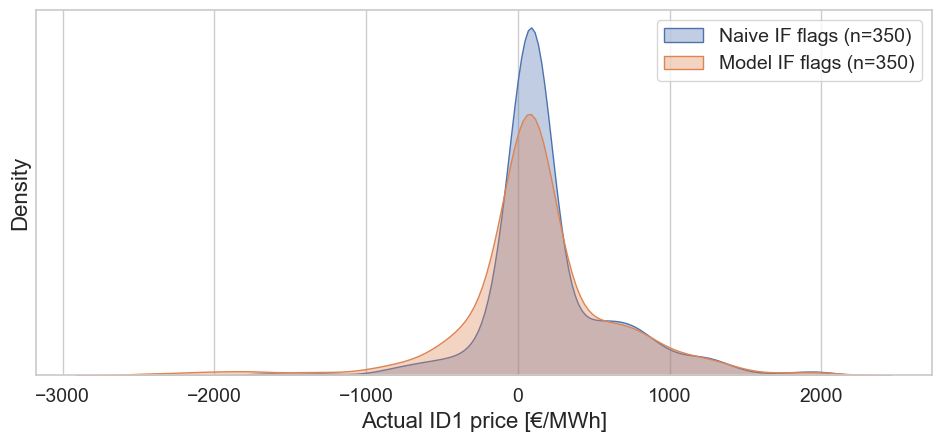


==================== IF GARCH ====================
Overlap: 286 points (81.71%)
Jaccard index: 0.6908
Naive abs. residual mean/median/max: 79.70 / 37.49 / 1590.98
Model abs. residual mean/median/max: 61.50 / 31.98 / 1255.85
Naive flagged actual price mean/median/min/max: 85.70 / 93.08 / -1306.94 / 1729.85
Model flagged actual price mean/median/min/max: 85.92 / 95.67 / -1306.94 / 1170.59


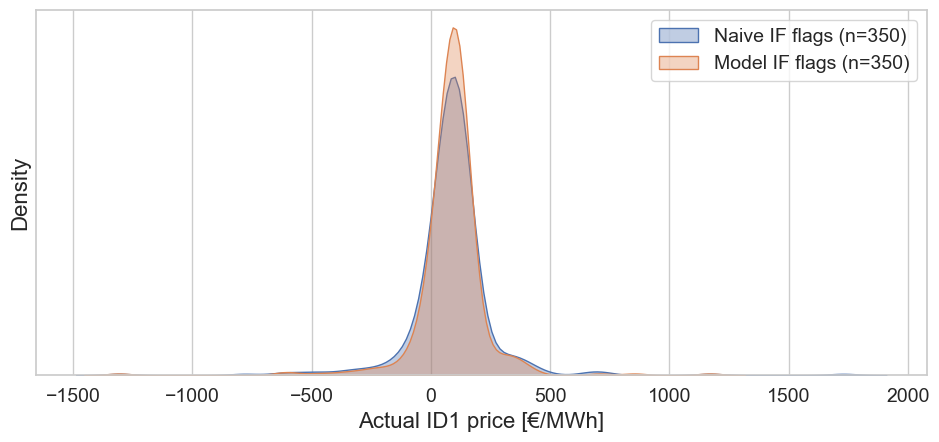

In [18]:
# =========================================================
# 8. IF DEEP DIVE
# =========================================================

def analyze_if_scenario(flags_naive, flags_model, title):
    metrics = selection_metrics(flags_naive, flags_model)

    naive_abs_resid = work.loc[flags_naive, "naive_abs_resid"]
    model_abs_resid = work.loc[flags_model, "model_abs_resid"]

    naive_actuals = work.loc[flags_naive, "actual_price"]
    model_actuals = work.loc[flags_model, "actual_price"]

    print(f"\n{'=' * 20} {title} {'=' * 20}")
    print(f"Overlap: {metrics['overlap_n']} points ({metrics['overlap_rate_a']:.2%})")
    print(f"Jaccard index: {metrics['jaccard']:.4f}")

    print(
        "Naive abs. residual mean/median/max: "
        f"{naive_abs_resid.mean():.2f} / {naive_abs_resid.median():.2f} / {naive_abs_resid.max():.2f}"
    )
    print(
        "Model abs. residual mean/median/max: "
        f"{model_abs_resid.mean():.2f} / {model_abs_resid.median():.2f} / {model_abs_resid.max():.2f}"
    )

    print(
        "Naive flagged actual price mean/median/min/max: "
        f"{naive_actuals.mean():.2f} / {naive_actuals.median():.2f} / "
        f"{naive_actuals.min():.2f} / {naive_actuals.max():.2f}"
    )
    print(
        "Model flagged actual price mean/median/min/max: "
        f"{model_actuals.mean():.2f} / {model_actuals.median():.2f} / "
        f"{model_actuals.min():.2f} / {model_actuals.max():.2f}"
    )

    plt.figure(figsize=(10, 5))

    sns.kdeplot(
        naive_actuals,
        label=f"Naive IF flags (n={len(naive_actuals)})",
        fill=True,
        alpha=0.35,
    )

    sns.kdeplot(
        model_actuals,
        label=f"Model IF flags (n={len(model_actuals)})",
        fill=True,
        alpha=0.35,
    )

    plt.rcParams.update({
        "font.size": 26,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "legend.title_fontsize": 14,
    })

    # hide y axis since density values are not the focus here
    plt.gca().set_yticks([])


    #plt.title(f"Actual Price Distribution of IF-Flagged Points ({title})")
    plt.xlabel("Actual ID1 price [€/MWh]")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


analyze_if_scenario(flags_naive_if_raw, flags_model_if_raw, "IF Raw")
analyze_if_scenario(flags_naive_if_z, flags_model_if_z, "IF GARCH")

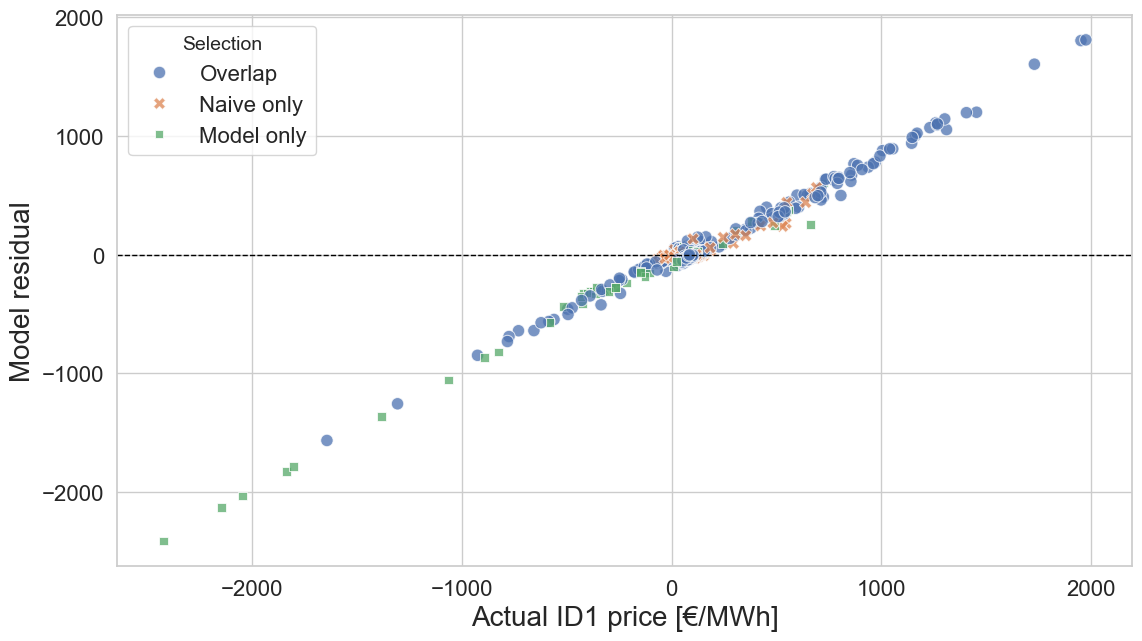

In [22]:
# =========================================================
# IF RAW SCATTERPLOT WITH SIGNED RESIDUALS
# =========================================================

plot_df = work.copy()

plot_df["flag_group"] = "Not flagged"

plot_df.loc[
    flags_naive_if_raw & ~flags_model_if_raw,
    "flag_group"
] = "Naive only"

plot_df.loc[
    ~flags_naive_if_raw & flags_model_if_raw,
    "flag_group"
] = "Model only"

plot_df.loc[
    flags_naive_if_raw & flags_model_if_raw,
    "flag_group"
] = "Overlap"


scatter_df = plot_df[
    plot_df["flag_group"] != "Not flagged"
].copy()


plt.figure(figsize=(12, 7))

plt.rcParams.update({
    "font.size": 26,
    "axes.titlesize": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 14,
})

sns.scatterplot(
    data=scatter_df,
    x="actual_price",
    y="model_resid",
    hue="flag_group",
    style="flag_group",
    s=80,
    alpha=0.75,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

#plt.title("IF Raw: Actual Price vs Model Residual")
plt.xlabel("Actual ID1 price [€/MWh]")
plt.ylabel("Model residual")
plt.legend(title="Selection")
plt.tight_layout()
plt.show()

## MAD and IQR quantity comparison

Compare the number of dynamically flagged outliers and their overlap for robust statistical thresholds.


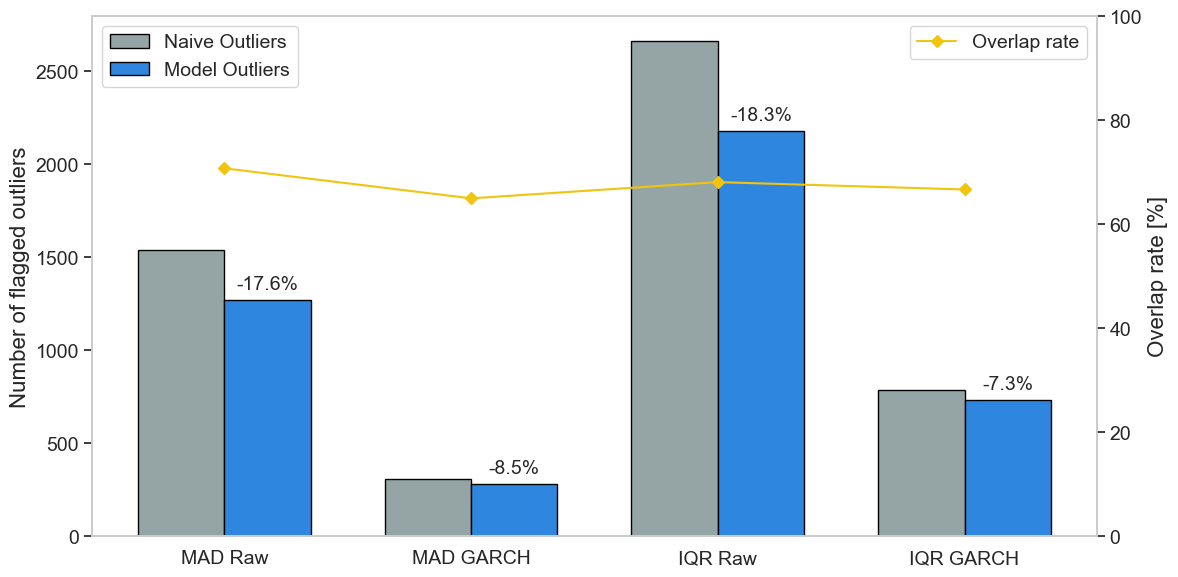

In [ ]:
# =========================================================
# 9. MAD AND IQR QUANTITY COMPARISON
# =========================================================

plot_df = results_df[results_df["scenario"].str.contains("MAD|IQR")].copy()
plot_df["scenario_label"] = plot_df["scenario"].str.replace("_", " ", regex=False)

x = np.arange(len(plot_df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(x - width/2, plot_df['naive_selected_n'], width, label='Naive Outliers', color='#95a5a6', edgecolor='black')
ax1.bar(x + width/2, plot_df['model_selected_n'], width, label='Model Outliers', color='#2e86de', edgecolor='black')

for i, row in plot_df.reset_index(drop=True).iterrows():
    ax1.annotate(
        f"{(-1*row['reduction_n_pct']):.1f}%",
        xy=(i + width / 2, row["model_selected_n"]),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

ax1.set_ylabel("Number of flagged outliers")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["scenario_label"])
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, plot_df["overlap_rate_a"] * 100, marker="D", color="#f1c40f", label="Overlap rate")
ax2.set_ylabel("Overlap rate [%]")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right")

# remove y-axis gridlines for cleaner look
ax1.grid(False)
ax2.grid(False)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 16,
})

#plt.title("MAD and IQR: Quantity Reduction and Overlap")
plt.tight_layout()
plt.show()